In [223]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [224]:
# Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns. set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors [0]
secondary_color = viridis_colors [1]
accent_color = viridis_colors [2]
danger_color = '#800000'
neutral_color = viridis_colors [4]
custom_palette = viridis_colors

In [225]:
DATA_PATH = "DataCoSupplyChainDataset.csv"
df_raw = pd.read_csv(DATA_PATH, encoding="latin1")

print("Shape:", df_raw.shape)
display(df_raw.head())

Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,"95,125.00",2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,"90,027.00",2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## Data understanding

In [226]:
print("Rows:", len(df_raw))
print("Columns:", df_raw.shape[1])
print("Duplicate rows:", df_raw.duplicated().sum())
print("Unique orders:", df_raw["Order Id"].nunique())
print("Unique customers:", df_raw["Customer Id"].nunique())
print("Unique products:", df_raw["Product Name"].nunique())

Rows: 180519
Columns: 53
Duplicate rows: 0
Unique orders: 65752
Unique customers: 20652
Unique products: 118


In [227]:
overview = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "unique": df_raw.nunique()
}).sort_values("missing_pct", ascending=False)
display(overview)

,dtype,missing,missing_pct,unique
Product Description,float64,180519,100.00,0
Order Zipcode,float64,155679,86.24,609
Days for shipment (scheduled),int64,0,0.00,4
Days for shipping (real),int64,0,0.00,7
Type,object,0,0.00,4
Delivery Status,object,0,0.00,4
Late_delivery_risk,int64,0,0.00,2
Category Id,int64,0,0.00,51
Category Name,object,0,0.00,50
Customer City,object,0,0.00,563


In [228]:
# Convert date columns to datetime
df_raw["order date (DateOrders)"] = pd.to_datetime(df_raw["order date (DateOrders)"],errors="coerce")

df_raw["shipping date (DateOrders)"] = pd.to_datetime(df_raw["shipping date (DateOrders)"],errors="coerce")

print("Order date range:",df_raw["order date (DateOrders)"].min(),"to",df_raw["order date (DateOrders)"].max())

print("\nShipping modes:"),display(df_raw["Shipping Mode"].value_counts(dropna=False).to_frame("records"))

print("\nDelivery status:")
display(df_raw["Delivery Status"].value_counts(dropna=False).to_frame("records"))

Order date range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00

Shipping modes:


,records
Shipping Mode,
Standard Class,107752
Second Class,35216
First Class,27814
Same Day,9737



Delivery status:


,records
Delivery Status,
Late delivery,98977
Advance shipping,41592
Shipping on time,32196
Shipping canceled,7754


## Data cleaning


In [229]:
drop_cols = [
    "Customer Email", "Customer Password", "Customer Fname", "Customer Lname",
    "Customer Street", "Customer Zipcode", "Product Description", "Product Image",
    "Order Zipcode"
]

df = df_raw.drop(columns=drop_cols).copy()

date_cols = ["order date (DateOrders)", "shipping date (DateOrders)"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

numeric_cols = [
    "Sales", "Sales per customer", "Benefit per order", "Product Price",
    "Order Item Product Price", "Order Item Quantity", "Order Item Discount",
    "Order Item Discount Rate", "Order Item Profit Ratio", "Order Item Total",
    "Order Profit Per Order", "Days for shipping (real)",
    "Days for shipment (scheduled)"]

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print(df.shape)

(180519, 44)


In [230]:
# Investigate duplicates before deciding to remove them.
print("Full-row duplicates:", df.duplicated().sum())
print("Duplicate Order Item IDs:", df["Order Item Id"].duplicated().sum())

# Remove exact full-row duplicates after inspection.
df = df.drop_duplicates().copy()

# Operational delivery analysis excludes shipping-canceled records.
df_operational = df[df["Delivery Status"].ne("Shipping canceled")].copy()
print("Cleaned full dataset:", df.shape)
print("Operational dataset:", df_operational.shape)

Full-row duplicates: 0
Duplicate Order Item IDs: 0
Cleaned full dataset: (180519, 44)
Operational dataset: (172765, 44)


## Handle missing values

In [231]:
missing = df_operational.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

,missing_count


In [232]:
essential_cols = [
    "Order Id", "Sales", "Order Profit Per Order", "Delivery Status",
    "Late_delivery_risk", "Shipping Mode", "Days for shipping (real)",
    "Days for shipment (scheduled)", "order date (DateOrders)"
]
before = len(df_operational)
df_operational = df_operational.dropna(subset=essential_cols).copy()
print("Rows removed for missing essential values:", before - len(df_operational))
print("Final operational rows:", len(df_operational))

Rows removed for missing essential values: 0
Final operational rows: 172765


## 6. Feature engineering

In [233]:
df_operational["Shipping_Delay_Days"] = (df_operational["Days for shipping (real)"] - df_operational["Days for shipment (scheduled)"])

df_operational["Is_Delayed"] = (df_operational["Shipping_Delay_Days"] > 0).astype(int)

df_operational["Profitability_Flag"] = np.select(
    [df_operational["Order Profit Per Order"] > 0, df_operational["Order Profit Per Order"] < 0], ["Profit", "Loss"], default="Breakeven")

order_dt = df_operational["order date (DateOrders)"]
df_operational["Order_Year"] = order_dt.dt.year
df_operational["Order_Month"] = order_dt.dt.month
df_operational["Order_Month_Name"] = order_dt.dt.month_name()
df_operational["Order_Quarter"] = order_dt.dt.quarter
df_operational["Order_Weekday"] = order_dt.dt.day_name()

df_operational["Profit_Margin_pct"] = np.where(df_operational["Sales"] != 0, df_operational["Order Profit Per Order"] / df_operational["Sales"] * 100, np.nan)

display(df_operational[["Shipping_Delay_Days", "Is_Delayed", "Profitability_Flag", "Order_Year", "Order_Month", "Order_Quarter", "Profit_Margin_pct"]].head())

,Shipping_Delay_Days,Is_Delayed,Profitability_Flag,Order_Year,Order_Month,Order_Quarter,Profit_Margin_pct
0,-1,0,Profit,2018,1,1,27.84
1,1,1,Loss,2018,1,1,-76.00
2,0,0,Loss,2018,1,1,-75.60
3,-1,0,Profit,2018,1,1,6.97
4,-2,0,Profit,2018,1,1,40.95


## KPIs

In [234]:
def calculate_kpis(data):
    sales = data["Sales"].sum()
    net_profit = data["Order Profit Per Order"].sum()
    total_loss = abs(data.loc[data["Order Profit Per Order"] < 0, "Order Profit Per Order"].sum())
    records = len(data)
    delayed = data["Is_Delayed"].sum()
    return pd.Series({
        "Unique Orders": data["Order Id"].nunique(),
        "Order-item Records": records,
        "Unique Customers": data["Customer Id"].nunique(),
        "Total Sales": f"${round(sales,2)}",
        "Net Profit": f"${round(net_profit,2)}",
        "Total Loss": f"${round(total_loss,2)}",
        "Profit Margin %": net_profit / sales * 100 if sales else np.nan,
        "Delayed Records": delayed,
        "Delay Rate %": delayed / records * 100 if records else np.nan,
        "Average Actual Shipping Days": data["Days for shipping (real)"].mean(),
        "Average Scheduled Shipping Days": data["Days for shipment (scheduled)"].mean(),
        "Average Delay Among Delayed": data.loc[data["Is_Delayed"] == 1, "Shipping_Delay_Days"].mean()
    })

kpis = calculate_kpis(df_operational)
display(kpis.to_frame("Value"))

,Value
Unique Orders,62897
Order-item Records,172765
Unique Customers,20261
Total Sales,$35214429.65
Net Profit,$3806420.63
Total Loss,$3708393.18
Profit Margin %,10.81
Delayed Records,98977
Delay Rate %,57.29
Average Actual Shipping Days,3.50


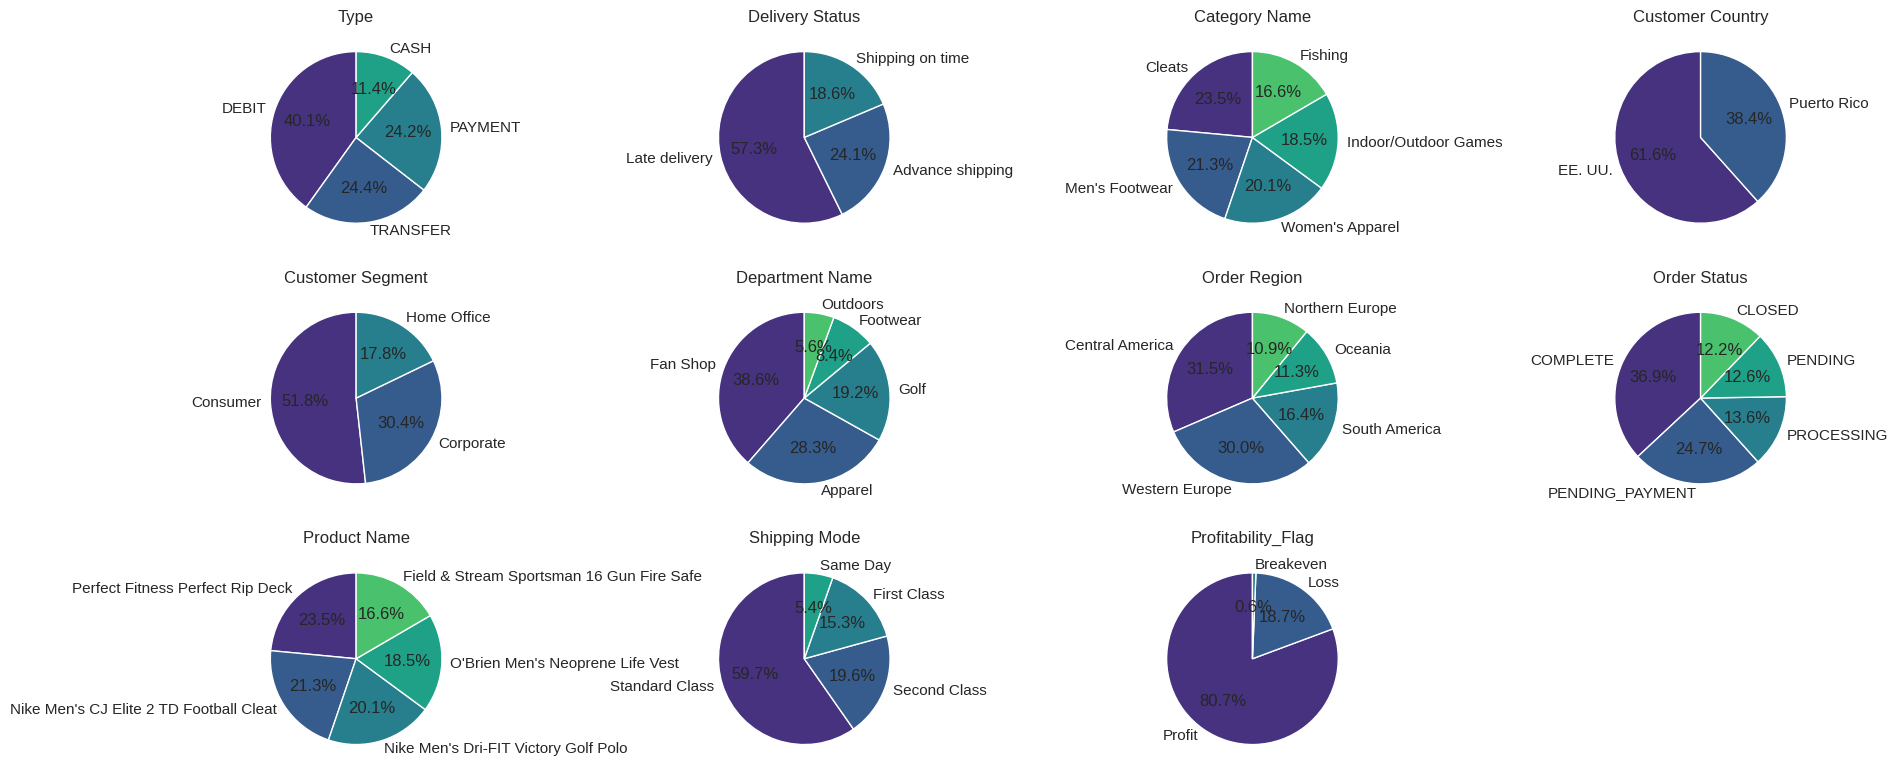

<Figure size 640x480 with 0 Axes>

In [235]:
# Pie chart:
pie_col = ['Type', 'Delivery Status', 'Category Name','Customer Country', 'Customer Segment','Department Name', 'Order Region',
           'Order Status','Product Name', 'Shipping Mode','Profitability_Flag']

plt.figure(figsize=(18,8))

for i, col in enumerate(pie_col):
    x = df_operational[col].value_counts()[:5]

    plt.subplot(3, 4, i + 1)
    plt.pie(x.values, labels=x.index, autopct='%1.1f%%', startangle=90)
    plt.title(col)

plt.tight_layout()
plt.show()
plt.savefig('01_Overall_analysis.png')


## Delivery performance overview

In [236]:
delivery_summary = (df_operational.groupby("Delivery Status").agg(records=("Order Id", "size"),unique_orders=("Order Id", "nunique"),
              sales=("Sales", "sum"),profit=("Order Profit Per Order", "sum"),avg_delay=("Shipping_Delay_Days", "mean")).reset_index())

delivery_summary["record_share_pct"] = delivery_summary["records"] / len(df_operational) * 100
display(delivery_summary.sort_values("records", ascending=False))

,Delivery Status,records,unique_orders,sales,profit,avg_delay,record_share_pct
1,Late delivery,98977,36048,"20,126,395.27","2,140,051.68",1.62,57.29
0,Advance shipping,41592,15127,"8,518,007.89","935,225.28",-1.50,24.07
2,Shipping on time,32196,11722,"6,570,026.50","731,143.67",0.00,18.64


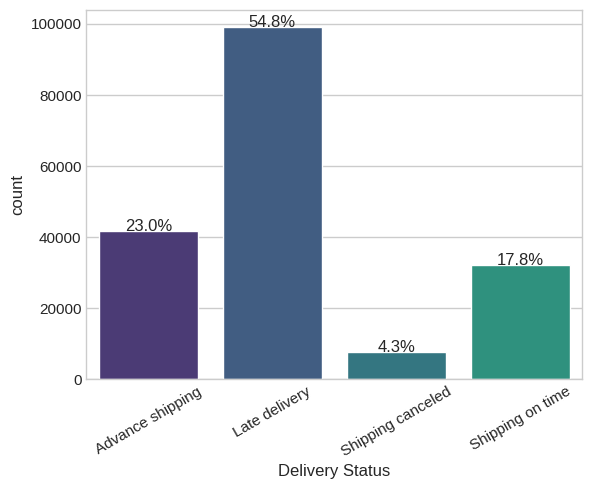

<Figure size 640x480 with 0 Axes>

In [237]:
# Analyzing Delivery status
ship_type = df.groupby('Delivery Status').size().reset_index(name='count')
ship_pct = round(ship_type['count']/ship_type['count'].sum() *100,2).to_list()

sns.barplot(x = 'Delivery Status', y= 'count' ,data=ship_type,hue='Delivery Status')
plt.xticks(rotation=30)

for i in range(len(ship_pct)):
    plt.text(
        i,
        ((ship_pct[i] * ship_type['count'].sum()) / 100) + 70,
        f'{ship_pct[i]:.1f}%',
        ha='center'
    )

plt.show()
plt.savefig('02_Shipping_type.png')

## Shipping delay distribution

In [238]:
display(df_operational["Shipping_Delay_Days"].value_counts().sort_index().to_frame("records"))

,records
Shipping_Delay_Days,
-2,20873
-1,20719
0,32196
1,57957
2,27551
3,6772
4,6697


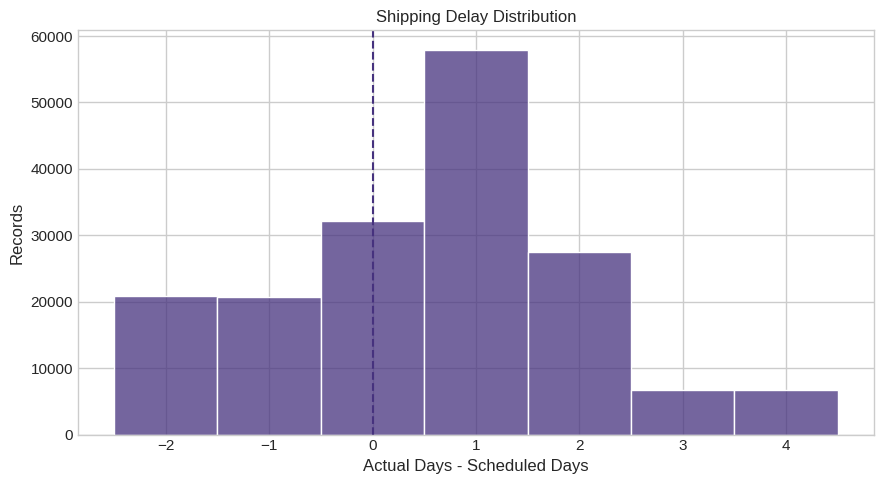

<Figure size 640x480 with 0 Axes>

In [239]:
plt.figure(figsize=(9,5))
sns.histplot(data=df_operational, x="Shipping_Delay_Days", discrete=True,edgecolor='white')
plt.axvline(0, linestyle="--")
plt.title("Shipping Delay Distribution")
plt.xlabel("Actual Days - Scheduled Days")
plt.ylabel("Records")
plt.tight_layout()

plt.show()
plt.savefig('03_Shipping_delay_distribution.png')

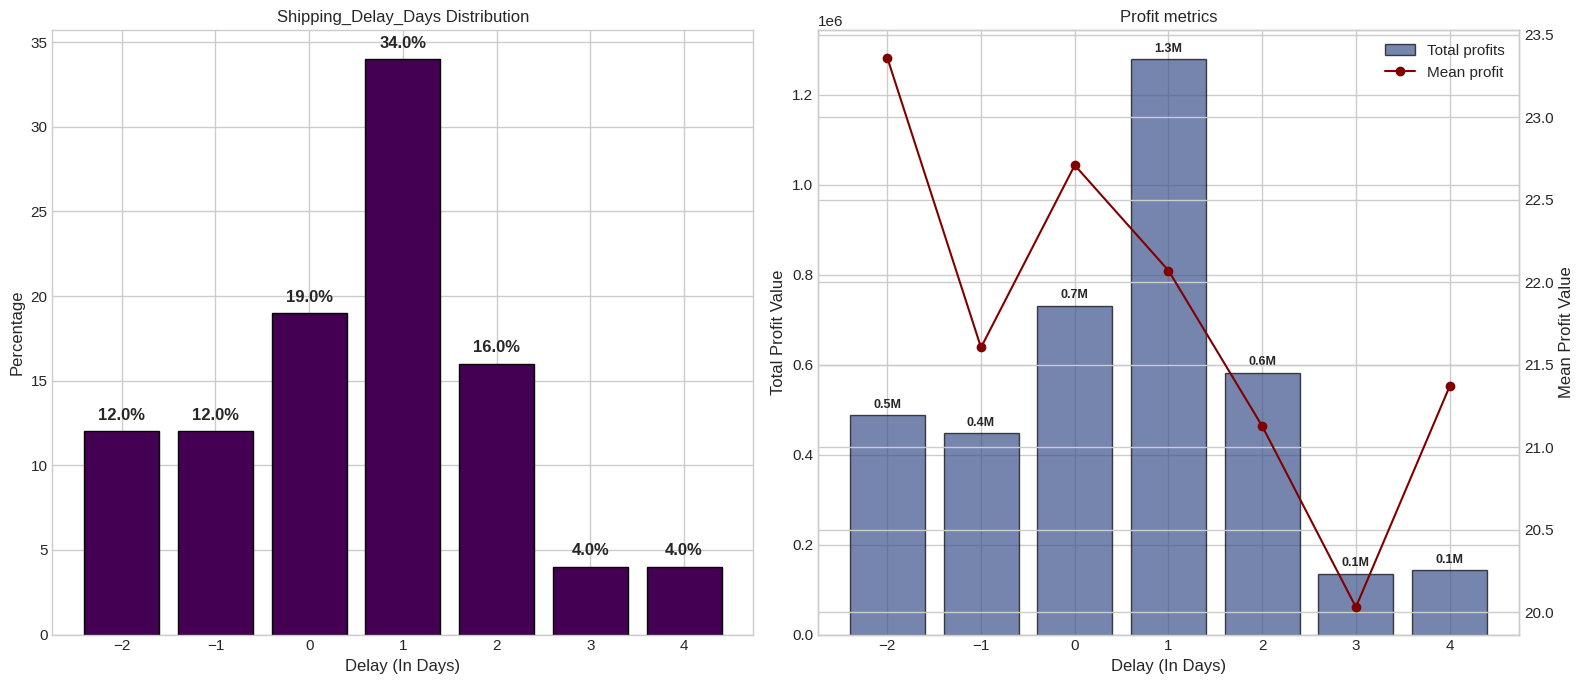

<Figure size 640x480 with 0 Axes>

In [240]:
delay_distribution = round((df_operational['Shipping_Delay_Days'].value_counts(normalize=True).sort_index()*100).reset_index())

profit_metrics = df_operational.groupby('Shipping_Delay_Days')['Order Profit Per Order'].agg({'sum','mean','count'}).reset_index()

plt.figure(figsize=(16,7))


ax1 = plt.subplot(1,2,1)
bars1 = ax1.bar(delay_distribution['Shipping_Delay_Days'], delay_distribution['proportion'], edgecolor='black', color=primary_color)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha='center', va='bottom', fontweight='bold')
ax1.set_title('Shipping_Delay_Days Distribution')
ax1.set_xlabel('Delay (In Days)')
ax1.set_ylabel('Percentage')


ax2_1 = plt.subplot(1,2,2)
ax2_2 = ax2_1.twinx()


bars2 = ax2_1.bar(profit_metrics['Shipping_Delay_Days'], profit_metrics['sum'], edgecolor='black', label='Total profits', alpha=0.7, color=secondary_color)

line2, = ax2_2.plot(profit_metrics['Shipping_Delay_Days'], profit_metrics['mean'], color=danger_color, marker='o', label='Mean profit')

for bar in bars2:
    yval = bar.get_height()
    ax2_1.text(bar.get_x() + bar.get_width()/2, yval + 10000, f'{yval/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')


ax2_1.set_title('Profit metrics')
ax2_1.set_xlabel('Delay (In Days)')
ax2_1.set_ylabel('Total Profit Value')
ax2_2.set_ylabel('Mean Profit Value')

ax2_1.legend([bars2, line2], ['Total profits', 'Mean profit'], loc='upper right')

plt.tight_layout()
plt.show()
plt.savefig('04_Delay_distribution&mean_profit.png')


## Shipping mode performance — counts and rates

In [241]:
shipping_mode = (df_operational.groupby("Shipping Mode")
    .agg(
        records=("Order Id", "size"),
        unique_orders=("Order Id", "nunique"),
        delayed_records=("Is_Delayed", "sum"),
        avg_actual_days=("Days for shipping (real)", "mean"),
        avg_scheduled_days=("Days for shipment (scheduled)", "mean"),
        avg_delay=("Shipping_Delay_Days", "mean"),
        sales=("Sales", "sum"),
        profit=("Order Profit Per Order", "sum")
    )
    .reset_index()
)
shipping_mode["delay_rate_pct"] = shipping_mode["delayed_records"] / shipping_mode["records"] * 100
display(shipping_mode.sort_values("delay_rate_pct", ascending=False))

,Shipping Mode,records,unique_orders,delayed_records,avg_actual_days,avg_scheduled_days,avg_delay,sales,profit,delay_rate_pct
0,First Class,26513,9602,26513,2.00,1.00,1.00,"5,408,068.56","616,596.73",100.00
2,Second Class,33806,12256,26987,3.99,2.00,1.99,"6,860,661.56","722,861.47",79.83
1,Same Day,9293,3407,4454,0.48,0.00,0.48,"1,854,872.21","194,182.13",47.93
3,Standard Class,103153,37632,41023,3.99,4.00,-0.01,"21,090,827.32","2,272,780.30",39.77


In [242]:
df_operational.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Id,Customer Segment,Customer State,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Shipping_Delay_Days,Is_Delayed,Profitability_Flag,Order_Year,Order_Month,Order_Month_Name,Order_Quarter,Order_Weekday,Profit_Margin_pct
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,-1,0,Profit,2018,1,January,1,Wednesday,27.84
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,1,1,Loss,2018,1,January,1,Saturday,-76.00
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,0,0,Loss,2018,1,January,1,Saturday,-75.60
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,-1,0,Profit,2018,1,January,1,Saturday,6.97
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,-2,0,Profit,2018,1,January,1,Saturday,40.95


In [243]:
def delay_analysis(category):

    if 'Is_Delayed' not in df_operational.columns:
        df_operational['Is_Delayed'] = (df_operational['Shipping_Delay_Days'] > 0).astype(int)

    result = (
        df_operational.groupby(category)
        .agg(
            total_orders=('Is_Delayed', 'count'),
            delayed_orders=('Is_Delayed', 'sum')
        )
        .reset_index()
    )

    result['delay_rate'] = (
        result['delayed_orders']
        / result['total_orders']
        * 100
    )

    return result.sort_values(
        'delay_rate',
        ascending=False
    )

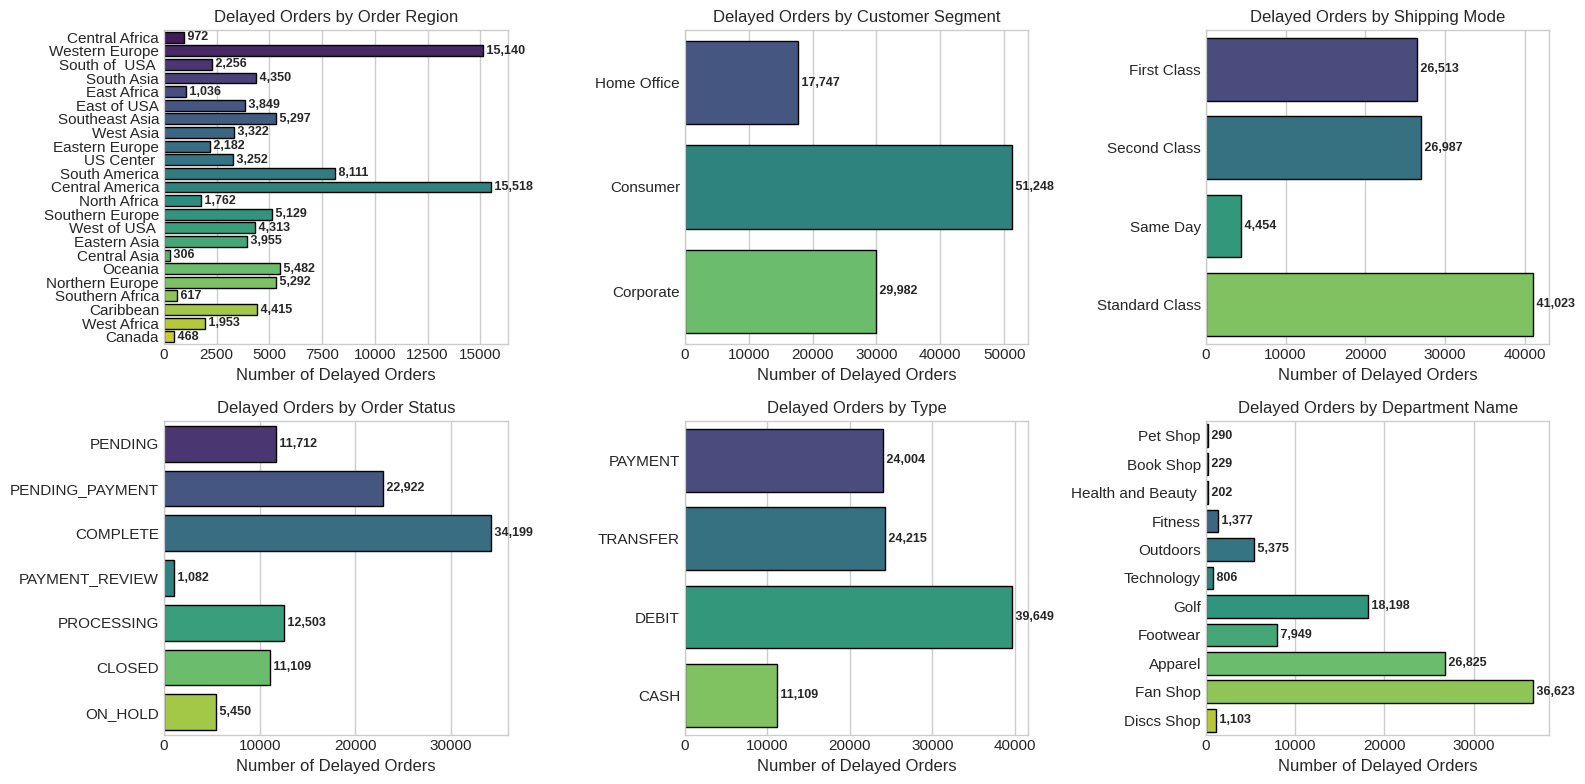

<Figure size 640x480 with 0 Axes>

In [244]:
categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 8),
    constrained_layout=True
)

axes = axes.flatten()

for ax, category in zip(axes, categories):

    cat_df = delay_analysis(category)

    sns.barplot(
        data=cat_df,
        x='delayed_orders',
        y=category,
        hue=category,
        legend=False,
        ax=ax,
        palette='viridis',
        edgecolor='black'
    )

    ax.set_title(f'Delayed Orders by {category}')
    ax.set_xlabel('Number of Delayed Orders')
    ax.set_ylabel('')

    # Labels
    for i, value in enumerate(cat_df['delayed_orders']):
        ax.text(value,i,f' {value:,}',va='center',fontsize=9,fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig('05_Bottleneck_analysis.png')


In [245]:
plot_data

,Shipping Mode,records,unique_orders,delayed_records,avg_actual_days,avg_scheduled_days,avg_delay,sales,profit,delay_rate_pct
0,First Class,26513,9602,26513,2.00,1.00,1.00,"5,408,068.56","616,596.73",100.00
2,Second Class,33806,12256,26987,3.99,2.00,1.99,"6,860,661.56","722,861.47",79.83
1,Same Day,9293,3407,4454,0.48,0.00,0.48,"1,854,872.21","194,182.13",47.93
3,Standard Class,103153,37632,41023,3.99,4.00,-0.01,"21,090,827.32","2,272,780.30",39.77


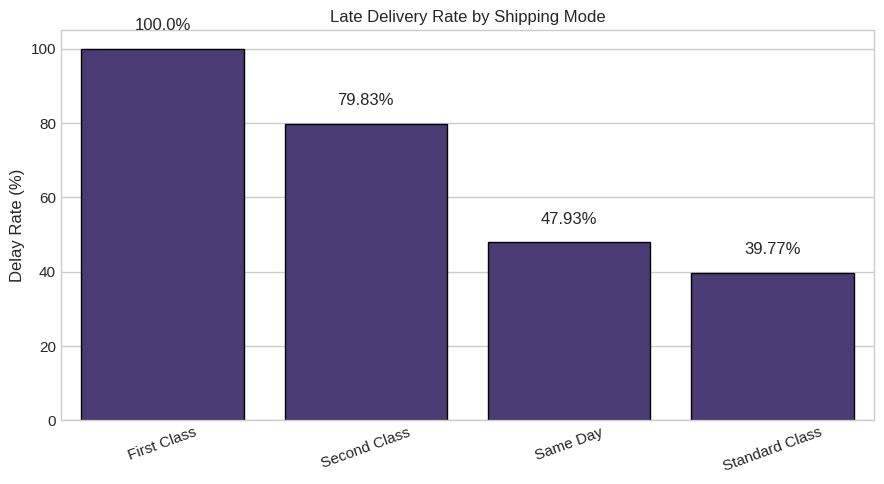

<Figure size 640x480 with 0 Axes>

In [246]:
plt.figure(figsize=(9,5))
plot_data = shipping_mode.sort_values("delay_rate_pct", ascending=False)
sns.barplot(data=plot_data, x="Shipping Mode", y="delay_rate_pct",edgecolor='black')
plt.title("Late Delivery Rate by Shipping Mode")
plt.xlabel("")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=20)
for i in range(len(plot_data['records'])):
  plt.text(i,plot_data['delay_rate_pct'].iloc[i]+5,f"{round(plot_data['delay_rate_pct'].iloc[i],2)}%",ha='center')
plt.tight_layout()
plt.show()
plt.savefig('06_Late_deliveryrate_by_shippingmode.png')

## Reusable bottleneck analysis

In [247]:
def bottleneck_analysis(data, dimension):
    result = (
        data.groupby(dimension)
        .agg(
            total_records=("Is_Delayed", "size"),
            delayed_records=("Is_Delayed", "sum"),
            avg_delay=("Shipping_Delay_Days", "mean"),
            sales=("Sales", "sum"),
            profit=("Order Profit Per Order", "sum")
        )
        .reset_index()
    )
    result["delay_rate_pct"] = result["delayed_records"] / result["total_records"] * 100
    return result.sort_values(["delay_rate_pct", "delayed_records"], ascending=[False, False])

for dimension in ["Order Region", "Category Name", "Department Name", "Customer Segment"]:
    print(f"\n--- {dimension} ---")
    display(bottleneck_analysis(df_operational, dimension).head(15))


--- Order Region ---


,Order Region,total_records,delayed_records,avg_delay,sales,profit,delay_rate_pct
2,Central Africa,1616,972,0.63,"315,769.36","32,429.41",60.15
22,Western Europe,25867,15140,0.60,"5,628,938.55","607,319.63",58.53
14,South of USA,3855,2256,0.60,"748,217.15","82,371.00",58.52
13,South Asia,7455,4350,0.60,"1,498,811.04","158,754.74",58.35
5,East Africa,1781,1036,0.59,"363,376.45","41,892.29",58.17
6,East of USA,6617,3849,0.59,"1,313,179.39","148,772.65",58.17
15,Southeast Asia,9136,5297,0.56,"1,850,920.76","202,242.88",57.98
20,West Asia,5746,3322,0.58,"1,122,755.80","115,462.14",57.81
8,Eastern Europe,3785,2182,0.59,"747,370.89","76,854.71",57.65
18,US Center,5653,3252,0.60,"1,107,813.81","126,356.86",57.53



--- Category Name ---


,Category Name,total_records,delayed_records,avg_delay,sales,profit,delay_rate_pct
23,Golf Bags & Carts,61,42,0.77,"10,369.39","1,810.07",68.85
32,Lacrosse,329,206,0.66,"38,015.22","4,095.84",62.61
37,Pet Supplies,472,290,0.70,"39,836.80","3,505.18",61.44
8,Cameras,562,344,0.62,"254,046.48","29,604.43",61.21
0,Accessories,1697,1014,0.60,"128,073.75","15,752.16",59.75
36,Music,417,248,0.58,"108,691.05","14,094.01",59.47
19,Fitness Accessories,296,176,0.62,"34,481.76","5,287.46",59.46
6,Boxing & MMA,402,238,0.67,"81,726.82","7,928.38",59.20
15,Crafts,458,271,0.62,"211,357.85","25,473.88",59.17
1,As Seen on TV!,66,39,0.70,"19,898.01","1,448.52",59.09



--- Department Name ---


,Department Name,total_records,delayed_records,avg_delay,sales,profit,delay_rate_pct
9,Pet Shop,472,290,0.70,"39,836.80","3,505.18",61.44
1,Book Shop,391,229,0.57,"12,152.28",854.44,58.57
7,Health and Beauty,346,202,0.52,"101,391.84","9,281.12",58.38
4,Fitness,2374,1377,0.59,"380,159.72","45,270.16",58.00
8,Outdoors,9267,5375,0.58,"1,200,937.91","141,336.69",58.00
10,Technology,1396,806,0.57,"994,974.41","111,588.83",57.74
6,Golf,31768,18198,0.56,"4,407,982.24","476,328.82",57.28
5,Footwear,13891,7949,0.56,"3,833,832.17","388,979.27",57.22
0,Apparel,46884,26825,0.57,"7,631,674.11","845,530.37",57.22
3,Fan Shop,64033,36623,0.56,"16,392,418.43","1,759,600.96",57.19



--- Customer Segment ---


,Customer Segment,total_records,delayed_records,avg_delay,sales,profit,delay_rate_pct
2,Home Office,30817,17747,0.58,"6,238,683.70","665,735.97",57.59
0,Consumer,89420,51248,0.57,"18,264,367.26","1,982,863.62",57.31
1,Corporate,52528,29982,0.56,"10,711,378.69","1,157,821.04",57.08


In [248]:
new_pie_col = [
    'Type', 'Delivery Status', 'Category Name', 'Customer Segment',
    'Department Name', 'Order Status', 'Product Name',
    'Shipping Mode', 'Profitability_Flag'
]

def delay_by_region(region):
    df_region = df_operational[df_operational['Order Region'] == region]

    plt.figure(figsize=(18, 12))

    for i, col in enumerate(new_pie_col):
        plot_col = df_region[col].value_counts().head(5)

        plt.subplot(3, 3, i + 1)

        wedges, texts, autotexts = plt.pie(
            plot_col.values,
            labels=plot_col.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=viridis_colors,
            shadow=True
        )

        # Change percentage text
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')

        # Change category label text
        for text in texts:
            text.set_color('black')

        plt.title(col)

    plt.tight_layout()
    plt.show()
    plt.savefig(f'07_08_Bottleneck_analysis_{region}.png')


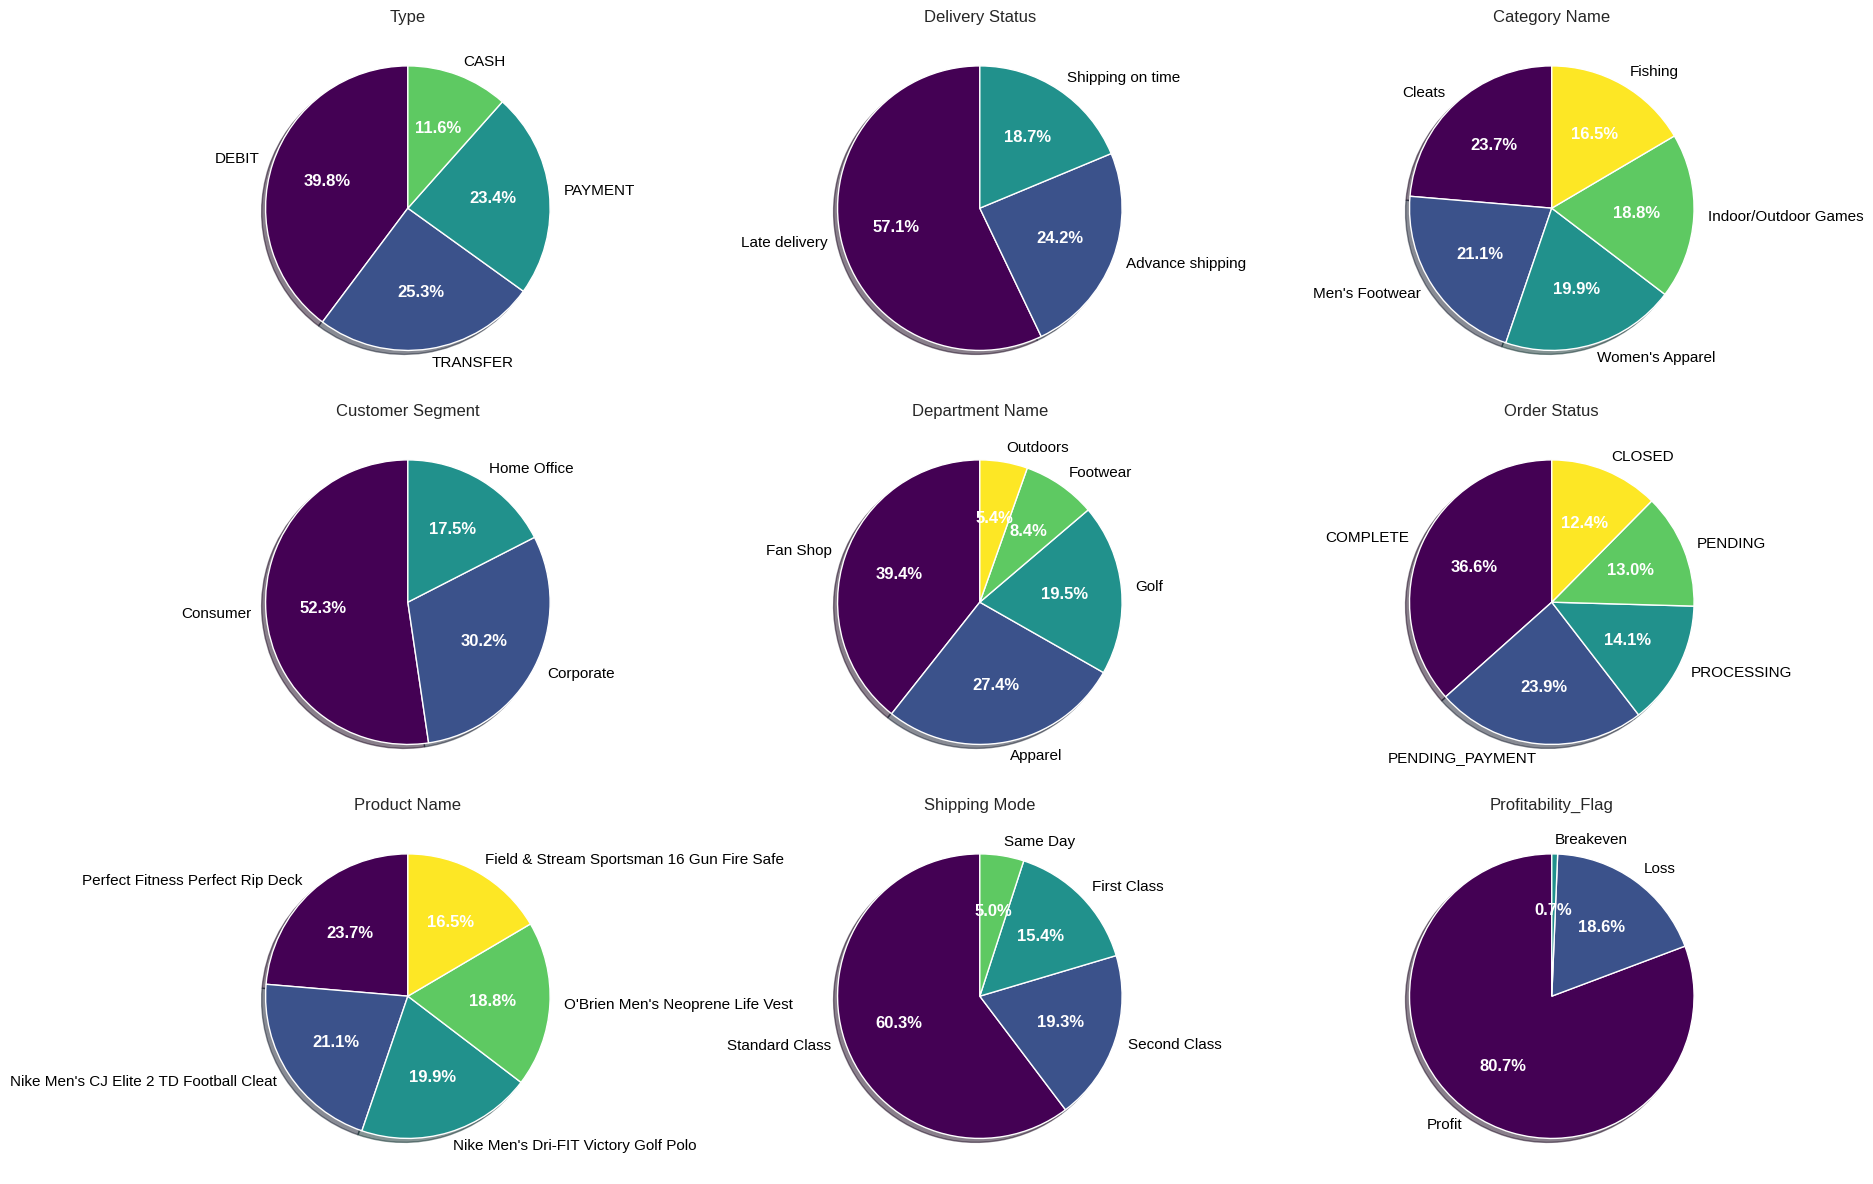

<Figure size 640x480 with 0 Axes>

In [249]:
# Central America

delay_by_region('Central America')

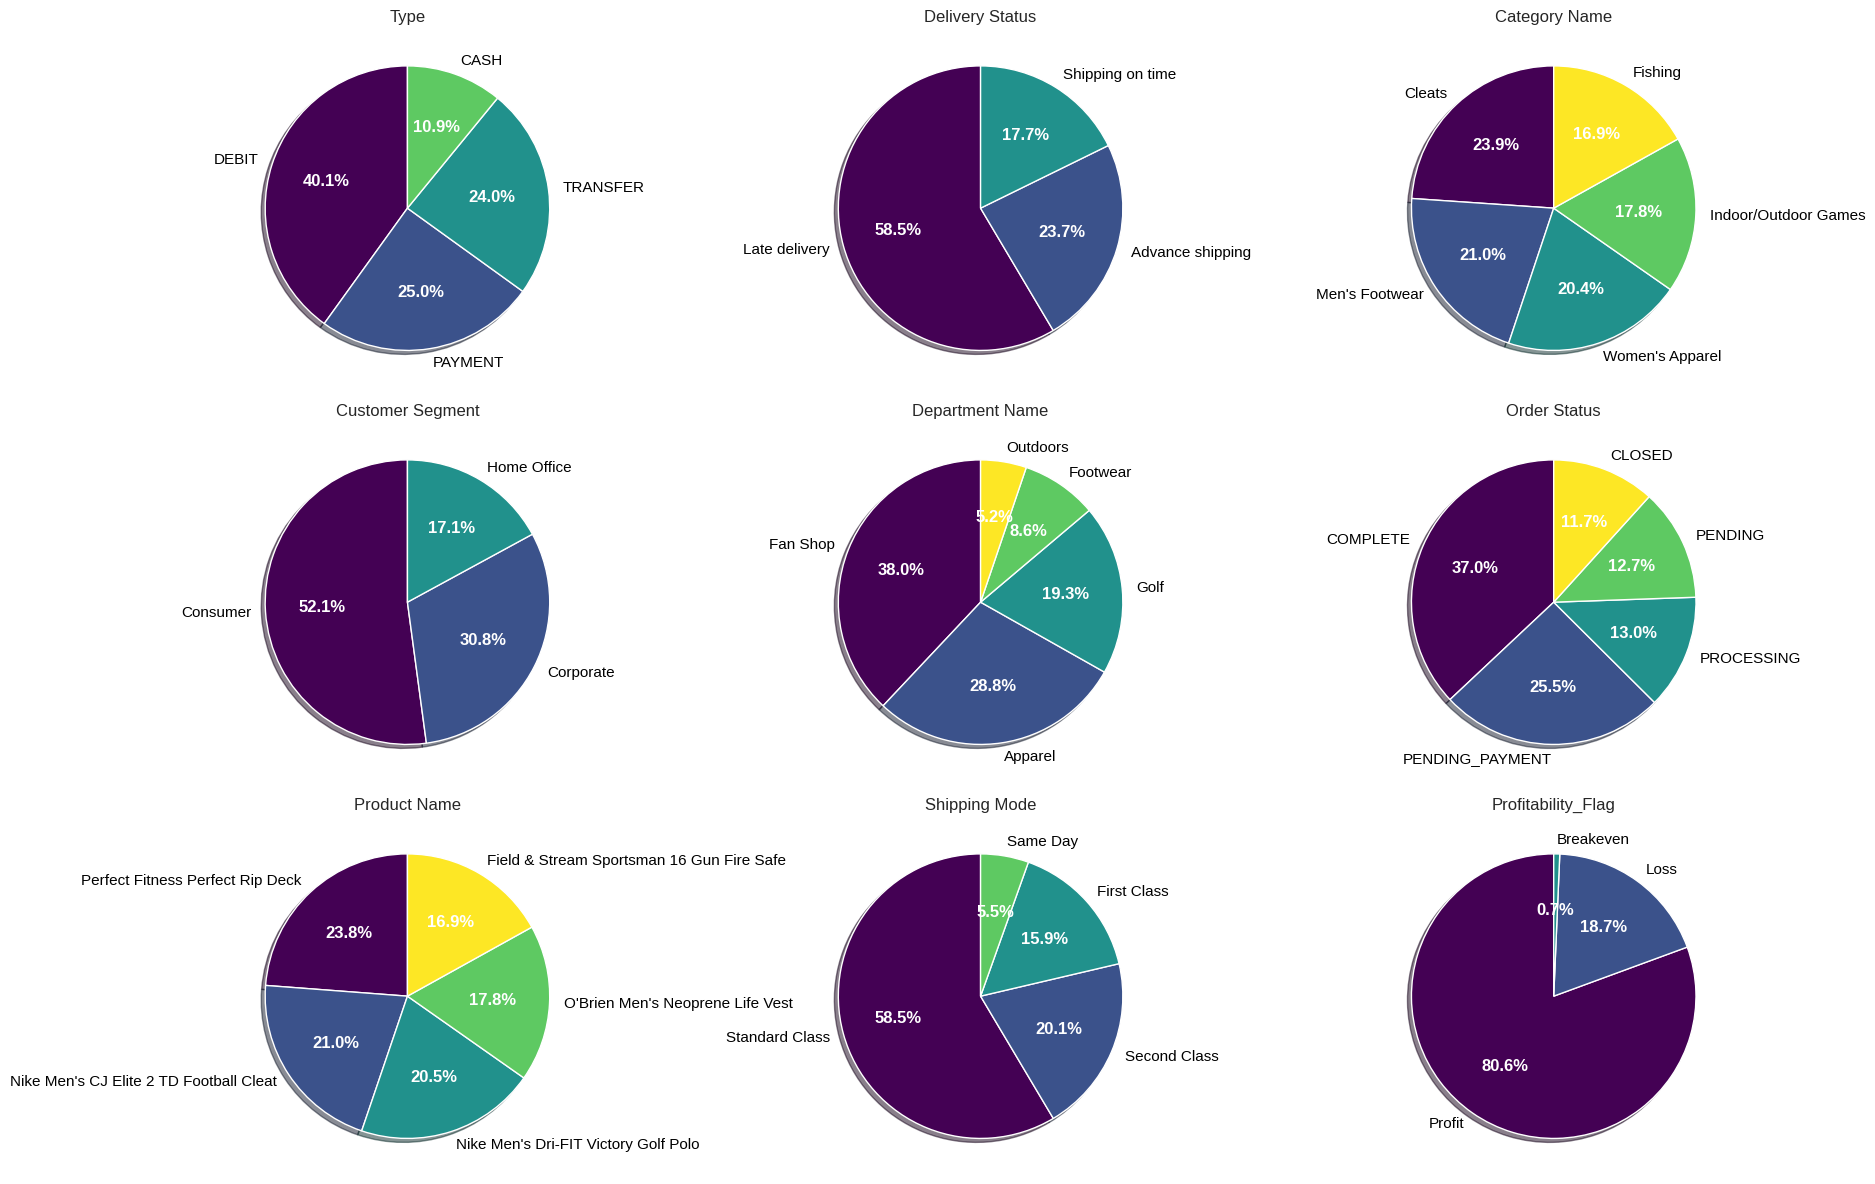

<Figure size 640x480 with 0 Axes>

In [250]:
# Western europe

delay_by_region('Western Europe')

## Region × Shipping Mode risk matrix

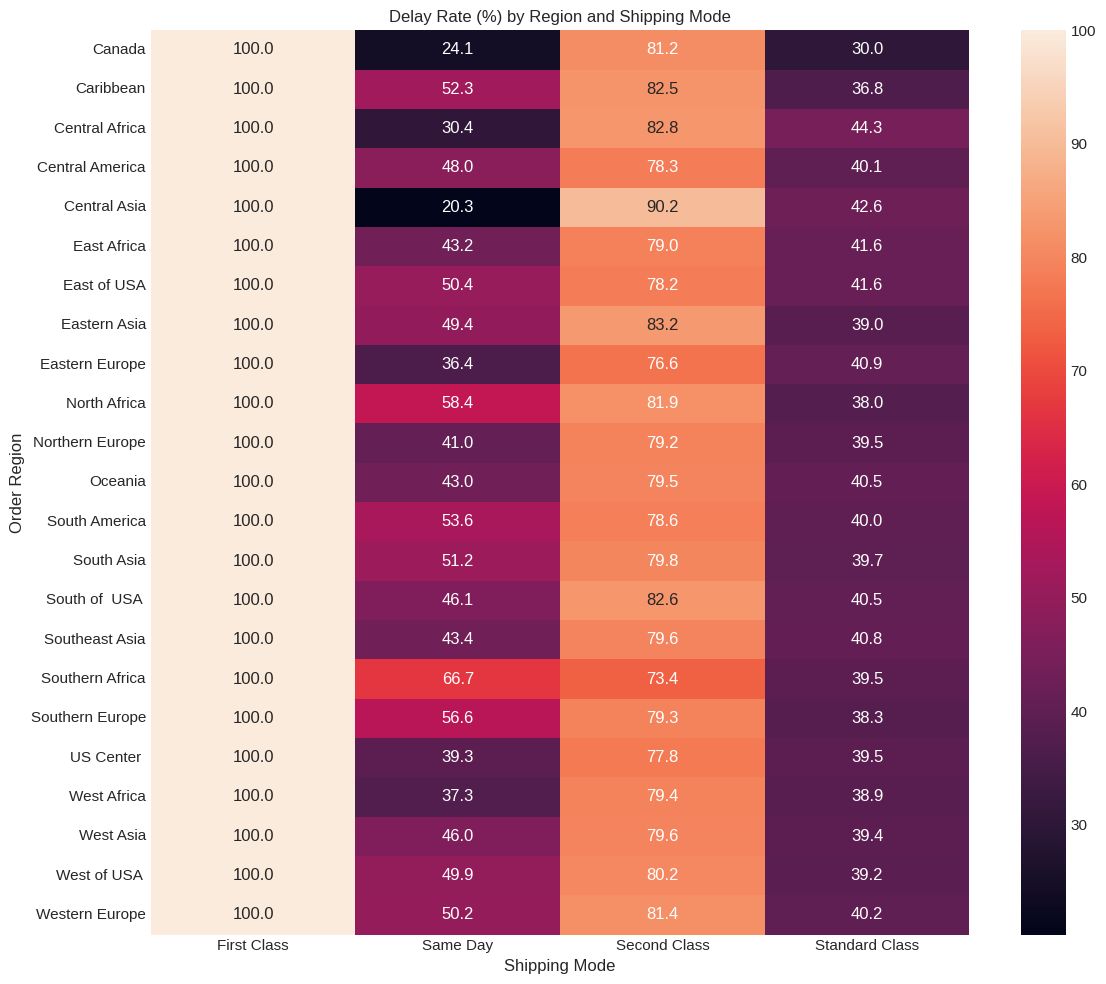

<Figure size 640x480 with 0 Axes>

In [251]:
region_shipping = (
    df_operational.groupby(["Order Region", "Shipping Mode"])
    .agg(total_records=("Is_Delayed", "size"), delayed_records=("Is_Delayed", "sum"))
    .reset_index()
)
region_shipping["delay_rate_pct"] = region_shipping["delayed_records"] / region_shipping["total_records"] * 100
heatmap_data = region_shipping.pivot(index="Order Region", columns="Shipping Mode", values="delay_rate_pct")

plt.figure(figsize=(12,10))
sns.heatmap(heatmap_data, annot=True, fmt=".1f")
plt.title("Delay Rate (%) by Region and Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Order Region")
plt.tight_layout()
plt.show()
plt.savefig('09_Heatmap_delayrate_by_region.png')

## Sales and category performance

In [252]:
sales_by_category = (
    df_operational.groupby("Category Name")
    .agg(sales=("Sales", "sum"), profit=("Order Profit Per Order", "sum"), quantity=("Order Item Quantity", "sum"))
    .reset_index()
    .sort_values("sales", ascending=False)
)
display(sales_by_category.head(15))

,Category Name,sales,profit,quantity
18,Fishing,"6,637,668.28","731,576.19",16595
12,Cleats,"4,244,594.01","474,629.51",70611
9,Camping & Hiking,"3,946,837.00","409,895.62",13157
10,Cardio Equipment,"3,533,289.21","362,984.70",35937
47,Women's Apparel,"3,011,600.00","334,335.53",60232
46,Water Sports,"2,981,851.28","308,981.34",14880
30,Indoor/Outdoor Games,"2,765,543.31","302,403.77",55333
34,Men's Footwear,"2,763,977.49","296,711.09",21263
38,Shop By Sport,"1,253,395.63","125,077.03",31329
13,Computers,"637,500.00","69,232.11",425


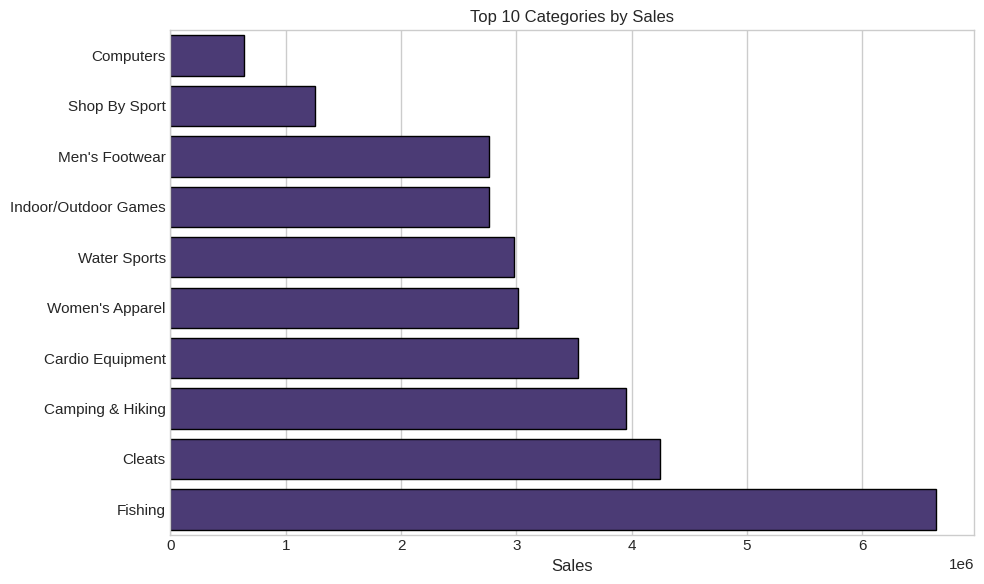

<Figure size 640x480 with 0 Axes>

In [253]:
top10 = sales_by_category.head(10).sort_values("sales")
plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="sales", y="Category Name",edgecolor='black')
plt.title("Top 10 Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("")
plt.tight_layout()
plt.show()
plt.savefig('10_Top_10_cat_by_sales.png')

## Profitability analysis

In [254]:
profit_summary = (
    df_operational.groupby("Profitability_Flag")
    .agg(records=("Order Id", "size"), sales=("Sales", "sum"), profit=("Order Profit Per Order", "sum"))
    .reset_index()
)
display(profit_summary)

,Profitability_Flag,records,sales,profit
0,Breakeven,1116,"221,222.92",0.00
1,Loss,32295,"6,563,195.67","-3,708,393.18"
2,Profit,139354,"28,430,011.06","7,514,813.81"


In [255]:
category_profit = (
    df_operational.groupby("Category Name")
    .agg(sales=("Sales", "sum"), profit=("Order Profit Per Order", "sum"), quantity=("Order Item Quantity", "sum"))
    .sort_values("profit", ascending=False).reset_index()
)
category_profit["profit_margin_pct"] = np.where(category_profit["sales"] != 0, category_profit["profit"] / category_profit["sales"] * 100, np.nan)


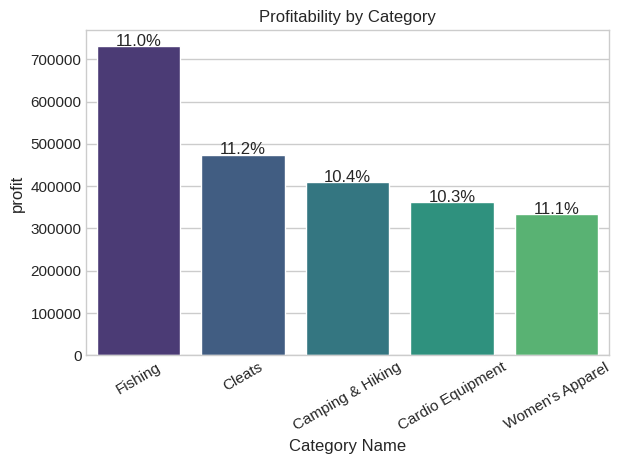

<Figure size 640x480 with 0 Axes>

In [256]:
sns.barplot(
    x='Category Name',
    y='profit',
    data=category_profit[:5],
    hue='Category Name',
    legend=False
)

plt.xticks(rotation=30)
plt.title("Profitability by Category")

for n, value in enumerate(category_profit['profit_margin_pct'][:5]):
    plt.text(
        n,
        category_profit['profit'].iloc[n] + 200,
        f'{value:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()
plt.savefig('11_Profitability_by_category.png')

## High-sales / low-profit categories

In [257]:
median_sales = category_profit["sales"].median()
median_profit = category_profit["profit"].median()

category_profit["performance_quadrant"] = np.select(
    [
        (category_profit["sales"] >= median_sales) & (category_profit["profit"] >= median_profit),
        (category_profit["sales"] >= median_sales) & (category_profit["profit"] < median_profit),
        (category_profit["sales"] < median_sales) & (category_profit["profit"] >= median_profit)
    ],
    ["High Sales / High Profit", "High Sales / Low Profit", "Low Sales / High Profit"],
    default="Low Sales / Low Profit"
)

display(category_profit[category_profit["performance_quadrant"] == "High Sales / Low Profit"])

,Category Name,sales,profit,quantity,profit_margin_pct,performance_quadrant
25,Health and Beauty,"101,391.84","9,281.12",346,9.15,High Sales / Low Profit


In [258]:
category_profit

,Category Name,sales,profit,quantity,profit_margin_pct,performance_quadrant
0,Fishing,"6,637,668.28","731,576.19",16595,11.02,High Sales / High Profit
1,Cleats,"4,244,594.01","474,629.51",70611,11.18,High Sales / High Profit
2,Camping & Hiking,"3,946,837.00","409,895.62",13157,10.39,High Sales / High Profit
3,Cardio Equipment,"3,533,289.21","362,984.70",35937,10.27,High Sales / High Profit
4,Women's Apparel,"3,011,600.00","334,335.53",60232,11.10,High Sales / High Profit
5,Water Sports,"2,981,851.28","308,981.34",14880,10.36,High Sales / High Profit
6,Indoor/Outdoor Games,"2,765,543.31","302,403.77",55333,10.93,High Sales / High Profit
7,Men's Footwear,"2,763,977.49","296,711.09",21263,10.73,High Sales / High Profit
8,Shop By Sport,"1,253,395.63","125,077.03",31329,9.98,High Sales / High Profit
9,Computers,"637,500.00","69,232.11",425,10.86,High Sales / High Profit


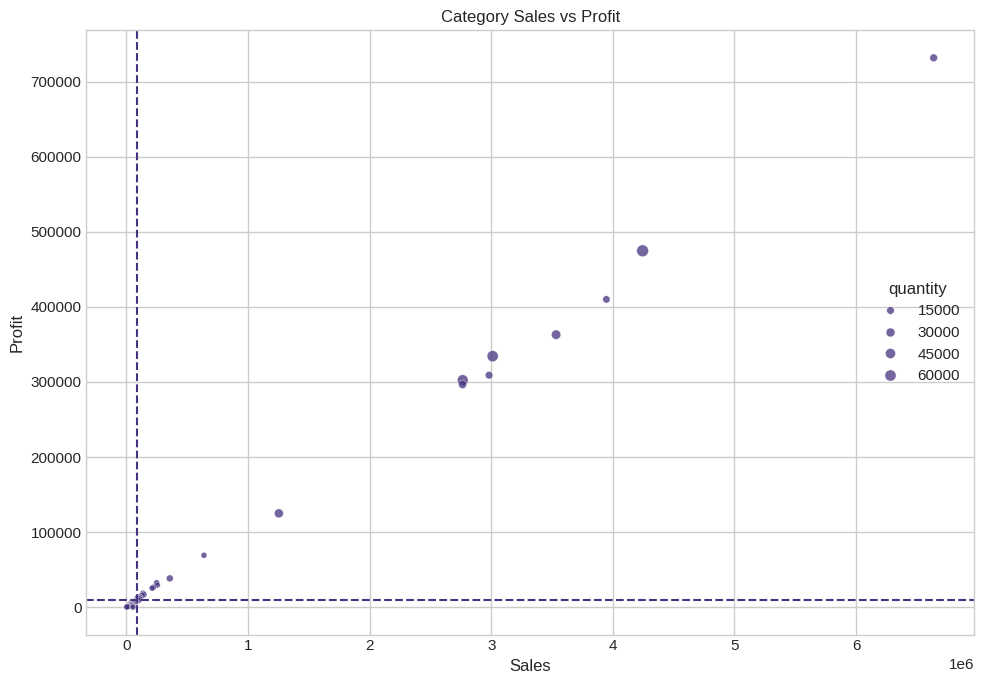

<Figure size 640x480 with 0 Axes>

In [259]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=category_profit, x="sales", y="profit", size="quantity", alpha=0.75)
plt.axvline(median_sales, linestyle="--")
plt.axhline(median_profit, linestyle="--")
plt.title("Category Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()
plt.savefig('12_Category_sales_vs_profit.png')

## Discount vs profitability

In [260]:
df_operational["Discount_Band"] = pd.cut(
    df_operational["Order Item Discount Rate"],
    bins=[-0.001, 0.05, 0.10, 0.15, 0.20, 0.30, 1.00],
    labels=["0-5%", "5-10%", "10-15%", "15-20%", "20-30%", "30%+"],
    include_lowest=True
)

discount_analysis = (
    df_operational.groupby("Discount_Band", observed=True)
    .agg(records=("Order Id", "size"), sales=("Sales", "sum"), avg_profit=("Order Profit Per Order", "mean"), total_profit=("Order Profit Per Order", "sum"))
    .reset_index()
)
display(discount_analysis)

,Discount_Band,records,sales,avg_profit,total_profit
0,0-5%,48024,"9,781,543.23",23.89,"1,147,311.03"
1,5-10%,38418,"7,833,269.62",23.58,"905,854.34"
2,10-15%,28717,"5,852,936.76",21.40,"614,557.67"
3,15-20%,38404,"7,830,273.46",20.21,"776,188.13"
4,20-30%,19202,"3,916,406.58",18.88,"362,509.46"


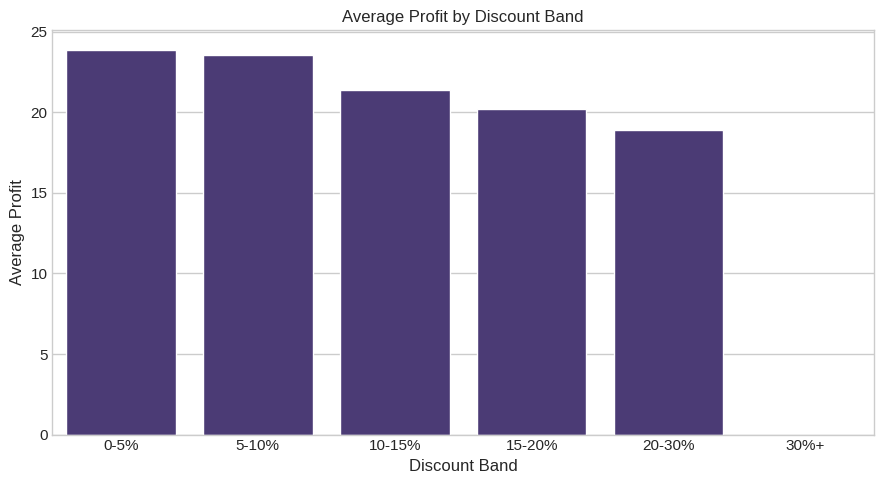

<Figure size 640x480 with 0 Axes>

In [261]:
plt.figure(figsize=(9,5))
sns.barplot(data=discount_analysis, x="Discount_Band", y="avg_profit")
plt.title("Average Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit")
plt.tight_layout()
plt.show()
plt.savefig('13_Avg_profit_by_Discount_rate.png')

## Customer segment analysis

In [262]:
customer_segment = (
    df_operational.groupby("Customer Segment")
    .agg(unique_orders=("Order Id", "nunique"), records=("Order Id", "size"), sales=("Sales", "sum"), profit=("Order Profit Per Order", "sum"), avg_sales_per_record=("Sales", "mean"), delayed_records=("Is_Delayed", "sum"))
    .reset_index()
)
customer_segment["delay_rate_pct"] = customer_segment["delayed_records"] / customer_segment["records"] * 100
customer_segment["profit_margin_pct"] = customer_segment["profit"] / customer_segment["sales"] * 100
display(customer_segment.sort_values("sales", ascending=False))

,Customer Segment,unique_orders,records,sales,profit,avg_sales_per_record,delayed_records,delay_rate_pct,profit_margin_pct
0,Consumer,32614,89420,"18,264,367.26","1,982,863.62",204.25,51248,57.31,10.86
1,Corporate,19017,52528,"10,711,378.69","1,157,821.04",203.92,29982,57.08,10.81
2,Home Office,11266,30817,"6,238,683.70","665,735.97",202.44,17747,57.59,10.67


## Product analysis

In [263]:
product_analysis = (
    df_operational.groupby("Product Name")
    .agg(unique_orders=("Order Id", "nunique"), quantity=("Order Item Quantity", "sum"), sales=("Sales", "sum"), profit=("Order Profit Per Order", "sum"), delayed_records=("Is_Delayed", "sum"))
    .reset_index()
)
product_analysis["delay_rate_pct"] = product_analysis["delayed_records"] / product_analysis["unique_orders"] * 100

print("Top products by sales")
display(product_analysis.sort_values("sales", ascending=False).head(10))
print("Top products by profit")
display(product_analysis.sort_values("profit", ascending=False).head(10))
print("Highest delay-rate products, minimum 100 unique orders")
display(product_analysis[product_analysis["unique_orders"] >= 100].sort_values("delay_rate_pct", ascending=False).head(10))

Top products by sales


,Product Name,unique_orders,quantity,sales,profit,delayed_records,delay_rate_pct
24,Field & Stream Sportsman 16 Gun Fire Safe,14527,16595,"6,637,668.28","731,576.19",9516,65.51
71,Perfect Fitness Perfect Rip Deck,19507,70575,"4,233,794.37","473,820.89",13473,69.07
21,Diamondback Women's Serene Classic Comfort Bi,11787,13157,"3,946,837.00","409,895.62",7487,63.52
61,Nike Men's Free 5.0+ Running Shoe,10606,35079,"3,507,549.21","359,793.63",6629,62.50
59,Nike Men's Dri-FIT Victory Golf Polo,17088,60232,"3,011,600.00","334,335.53",11476,67.16
70,Pelican Sunstream 100 Kayak,13143,14840,"2,967,851.68","307,910.75",8492,64.61
67,O'Brien Men's Neoprene Life Vest,15912,55333,"2,765,543.31","302,403.77",10565,66.40
56,Nike Men's CJ Elite 2 TD Football Cleat,17954,21263,"2,763,977.49","296,711.09",12121,67.51
102,Under Armour Girls' Toddler Spine Surge Runni,9401,30380,"1,214,896.22","121,834.27",5865,62.39
18,Dell Laptop,425,425,"637,500.00","69,232.11",224,52.71


Top products by profit


,Product Name,unique_orders,quantity,sales,profit,delayed_records,delay_rate_pct
24,Field & Stream Sportsman 16 Gun Fire Safe,14527,16595,"6,637,668.28","731,576.19",9516,65.51
71,Perfect Fitness Perfect Rip Deck,19507,70575,"4,233,794.37","473,820.89",13473,69.07
21,Diamondback Women's Serene Classic Comfort Bi,11787,13157,"3,946,837.00","409,895.62",7487,63.52
61,Nike Men's Free 5.0+ Running Shoe,10606,35079,"3,507,549.21","359,793.63",6629,62.50
59,Nike Men's Dri-FIT Victory Golf Polo,17088,60232,"3,011,600.00","334,335.53",11476,67.16
70,Pelican Sunstream 100 Kayak,13143,14840,"2,967,851.68","307,910.75",8492,64.61
67,O'Brien Men's Neoprene Life Vest,15912,55333,"2,765,543.31","302,403.77",10565,66.40
56,Nike Men's CJ Elite 2 TD Football Cleat,17954,21263,"2,763,977.49","296,711.09",12121,67.51
102,Under Armour Girls' Toddler Spine Surge Runni,9401,30380,"1,214,896.22","121,834.27",5865,62.39
18,Dell Laptop,425,425,"637,500.00","69,232.11",224,52.71


Highest delay-rate products, minimum 100 unique orders


,Product Name,unique_orders,quantity,sales,profit,delayed_records,delay_rate_pct
71,Perfect Fitness Perfect Rip Deck,19507,70575,"4,233,794.37","473,820.89",13473,69.07
56,Nike Men's CJ Elite 2 TD Football Cleat,17954,21263,"2,763,977.49","296,711.09",12121,67.51
59,Nike Men's Dri-FIT Victory Golf Polo,17088,60232,"3,011,600.00","334,335.53",11476,67.16
67,O'Brien Men's Neoprene Life Vest,15912,55333,"2,765,543.31","302,403.77",10565,66.40
89,Team Golf St. Louis Cardinals Putter Grip,297,920,"22,990.80","2,666.91",197,66.33
24,Field & Stream Sportsman 16 Gun Fire Safe,14527,16595,"6,637,668.28","731,576.19",9516,65.51
70,Pelican Sunstream 100 Kayak,13143,14840,"2,967,851.68","307,910.75",8492,64.61
40,Hirzl Women's Soffft Flex Golf Glove,284,855,"15,381.45","1,259.63",183,64.44
115,adidas Men's Germany Black Crest Away Tee,274,819,"20,475.00","2,586.62",176,64.23
21,Diamondback Women's Serene Classic Comfort Bi,11787,13157,"3,946,837.00","409,895.62",7487,63.52


## Geographic analysis

In [264]:
geo_region = (
    df_operational.groupby(["Market", "Order Region"])
    .agg(unique_orders=("Order Id", "nunique"), sales=("Sales", "sum"), profit=("Order Profit Per Order", "sum"), delayed_records=("Is_Delayed", "sum"), records=("Order Id", "size"))
    .reset_index()
)
geo_region["delay_rate_pct"] = geo_region["delayed_records"] / geo_region["records"] * 100
display(geo_region.sort_values("delay_rate_pct", ascending=False).head(20))

,Market,Order Region,unique_orders,sales,profit,delayed_records,records,delay_rate_pct
0,Africa,Central Africa,533,"315,769.36","32,429.41",972,1616,60.15
8,Europe,Western Europe,9563,"5,628,938.55","607,319.63",15140,25867,58.53
20,USCA,South of USA,1280,"748,217.15","82,371.00",2256,3855,58.52
15,Pacific Asia,South Asia,3219,"1,498,811.04","158,754.74",4350,7455,58.35
1,Africa,East Africa,589,"363,376.45","41,892.29",1036,1781,58.17
19,USCA,East of USA,2219,"1,313,179.39","148,772.65",3849,6617,58.17
16,Pacific Asia,Southeast Asia,4173,"1,850,920.76","202,242.88",5297,9136,57.98
17,Pacific Asia,West Asia,1935,"1,122,755.80","115,462.14",3322,5746,57.81
5,Europe,Eastern Europe,1246,"747,370.89","76,854.71",2182,3785,57.65
21,USCA,US Center,1852,"1,107,813.81","126,356.86",3252,5653,57.53


In [265]:
geo_country = (
    df_operational.groupby(["Market", "Order Country"])
    .agg(unique_orders=("Order Id", "nunique"), sales=("Sales", "sum"), profit=("Order Profit Per Order", "sum"), delay_rate_pct=("Is_Delayed", "mean"))
    .reset_index()
)
geo_country["delay_rate_pct"] *= 100
display(geo_country.sort_values("sales", ascending=False).head(20))

,Market,Order Country,unique_orders,sales,profit,delay_rate_pct
163,USCA,Estados Unidos,7887,"4,659,618.21","516,687.34",57.63
64,Europe,Francia,4648,"2,753,970.85","316,542.62",58.21
105,LATAM,México,4201,"2,522,997.51","289,017.94",57.49
50,Europe,Alemania,3368,"1,986,194.39","187,980.97",58.80
118,Pacific Asia,Australia,3633,"1,623,923.79","165,277.34",56.70
78,Europe,Reino Unido,2661,"1,544,403.72","174,689.14",55.82
90,LATAM,Brasil,2520,"1,513,085.23","175,032.64",57.14
124,Pacific Asia,China,2495,"1,123,516.47","117,357.10",56.79
68,Europe,Italia,1793,"1,021,387.17","116,445.92",56.10
130,Pacific Asia,India,2070,"925,155.50","94,874.24",58.49




## Time-series analysis

In [266]:
monthly = (
    df_operational.groupby(df_operational["order date (DateOrders)"].dt.to_period("M"))
    .agg(unique_orders=("Order Id", "nunique"), records=("Order Id", "size"), sales=("Sales", "sum"), profit=("Order Profit Per Order", "sum"), delayed_records=("Is_Delayed", "sum"))
    .reset_index()
    .rename(columns={"order date (DateOrders)": "Month"})
)
monthly["Month"] = monthly["Month"].astype(str)
monthly["delay_rate_pct"] = monthly["delayed_records"] / monthly["records"] * 100
display(monthly.head())

,Month,unique_orders,records,sales,profit,delayed_records,delay_rate_pct
0,2015-01,1713,5114,"1,008,854.43","105,773.57",2880,56.32
1,2015-02,1505,4487,"881,666.99","93,009.96",2594,57.81
2,2015-03,1702,5127,"1,007,758.05","107,401.92",2936,57.27
3,2015-04,1639,4915,"972,303.15","102,071.91",2760,56.15
4,2015-05,1684,5087,"996,912.91","108,951.47",2951,58.01


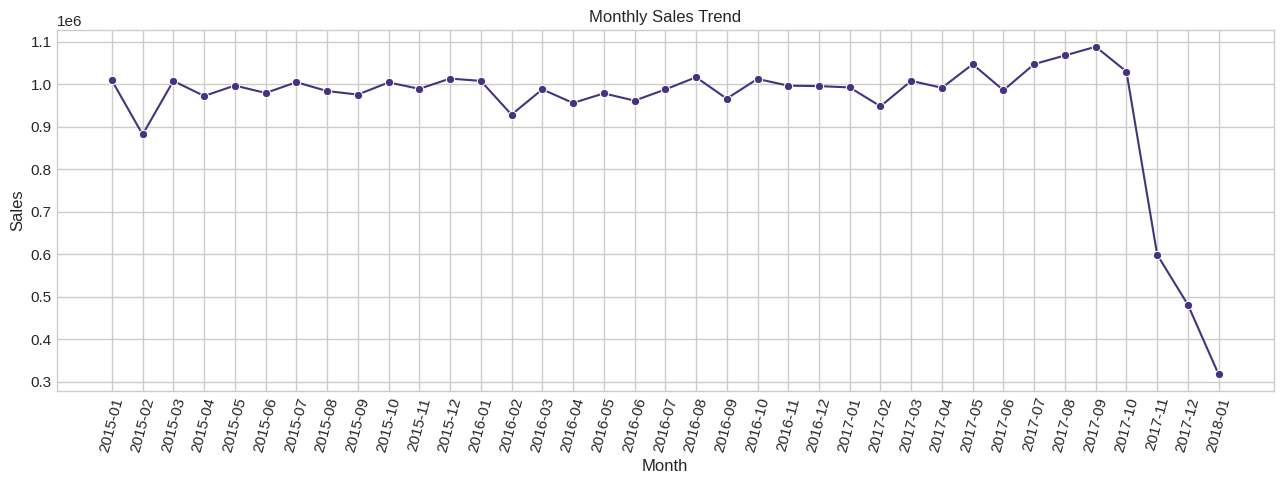

<Figure size 640x480 with 0 Axes>

In [267]:
plt.figure(figsize=(13,5))
sns.lineplot(data=monthly, x="Month", y="sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()
plt.savefig('14_monthly_sales.png')

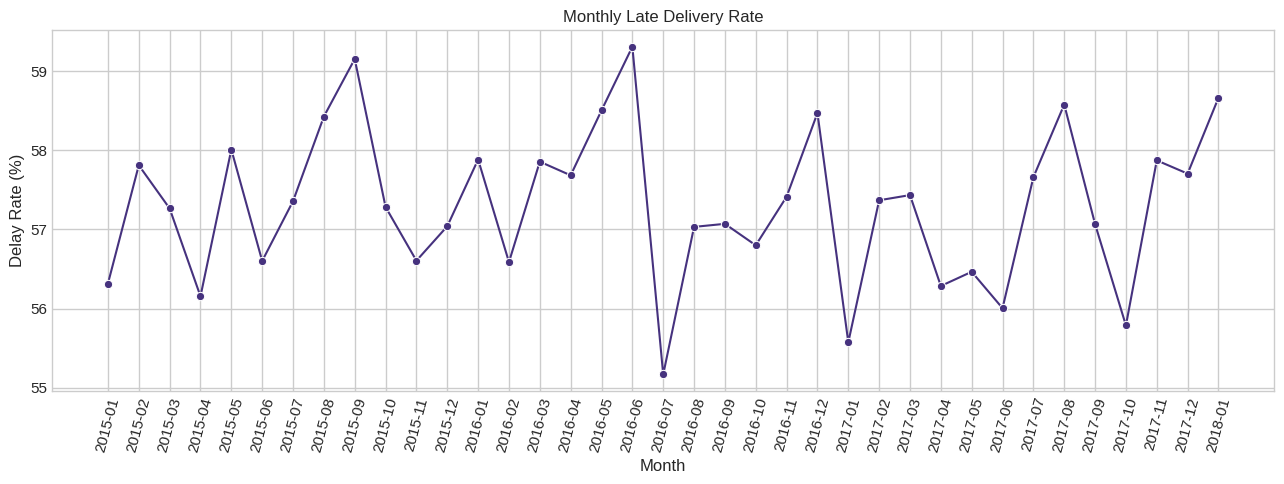

<Figure size 640x480 with 0 Axes>

In [268]:
plt.figure(figsize=(13,5))
sns.lineplot(data=monthly, x="Month", y="delay_rate_pct", marker="o")
plt.title("Monthly Late Delivery Rate")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()
plt.savefig('15_monthly_late_delivery_rate.png')

##  Delayed vs non-delayed comparison

In [269]:
delay_comparison = (
    df_operational.groupby("Is_Delayed")
    .agg(
        avg_sales=("Sales", "mean"),
        avg_profit=("Order Profit Per Order", "mean"),
        avg_quantity=("Order Item Quantity", "mean"),
        avg_discount_rate=("Order Item Discount Rate", "mean"),
        avg_product_price=("Product Price", "mean"),
        avg_scheduled_days=("Days for shipment (scheduled)", "mean"),
        avg_actual_days=("Days for shipping (real)", "mean")
    )
    .rename(index={0: "Not Delayed", 1: "Delayed"})
)
display(delay_comparison)

,avg_sales,avg_profit,avg_quantity,avg_discount_rate,avg_product_price,avg_scheduled_days,avg_actual_days
Is_Delayed,,,,,,,
Not Delayed,204.48,22.58,2.13,0.10,141.71,3.55,2.71
Delayed,203.34,21.62,2.13,0.10,140.96,2.47,4.09
